# 02 - Preprocessing
## Objectif : Sélectionner les variables pertinentes et préparer le dataset ML

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
print("✅ Imports OK")

✅ Imports OK


In [3]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

df = client.query_df("""
SELECT
    d.Year                              AS year,
    d.Month                             AS month,
    d.Quarter                           AS quarter,
    SUM(f.LinePrice)                    AS total_sales,
    SUM(f.Quantity)                     AS total_quantity,
    COUNT(DISTINCT f.DocumentCode)      AS nb_documents,
    COUNT(DISTINCT f.ClientSK)          AS nb_clients,
    COUNT(DISTINCT f.ItemSK)            AS nb_produits,
    COUNT(DISTINCT f.GeographicalAreaSK) AS nb_regions,
    COUNT(DISTINCT f.WarehouseSK)       AS nb_warehouses,
    AVG(f.DiscountPercentage)           AS avg_discount,
    SUM(f.DiscountAmount)               AS total_discount,
    SUM(f.CostPrice)                    AS total_cost,
    SUM(f.LinePrice - f.CostPrice)      AS total_marge
FROM gold.fact_sales AS f
JOIN gold.dim_date AS d ON f.DateSK = d.DateSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month, quarter
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
print(f"✅ {len(df)} mois chargés")
df.head()

✅ 51 mois chargés


,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,nb_produits,nb_regions,nb_warehouses,avg_discount,total_discount,total_cost,total_marge,date
0,2021,3,1,404.06,6,1,1,6,1,2,15.00,60.61,334.97,69.09,2021-03-01
1,2022,1,1,"591,407.94",10983,1125,197,3225,9,3,9.28,"44,802.24","604,390.30","-12,982.36",2022-01-01
2,2022,2,1,"576,097.45",10770,1263,190,3327,9,3,9.69,"36,225.76","677,038.55","-100,941.11",2022-02-01
3,2022,3,1,"680,213.89",11488,1304,200,3497,9,3,7.93,"40,184.68","683,998.33","-3,784.44",2022-03-01
4,2022,4,2,"650,789.55",11385,1093,224,3264,9,4,9.09,"47,939.71","638,230.20","12,559.36",2022-04-01


## 1. Nettoyage — Suppression des mois incomplets

In [4]:
print(f"Avant nettoyage : {len(df)} mois")
print(f"Mois incomplets :")
print(df[
    (df['date'] < '2022-01-01') | (df['date'] >= '2026-02-01')
][['date', 'total_sales']].to_string(index=False))

df = df[
    (df['date'] >= '2022-01-01') & (df['date'] < '2026-02-01')
].reset_index(drop=True)

print(f"\nAprès nettoyage : {len(df)} mois")
print(f"Période : {df['date'].min().strftime('%b %Y')} → {df['date'].max().strftime('%b %Y')}")

Avant nettoyage : 51 mois
Mois incomplets :
      date  total_sales
2021-03-01       404.06
2026-02-01   114,247.11

Après nettoyage : 49 mois
Période : Jan 2022 → Jan 2026


## 2. Sélection des variables pertinentes

In [5]:
# Variables directement disponibles sans feature engineering complexe
# On garde ce qui est métier-pertinent et statistiquement corrélé à total_sales

df_ml = df[[
    'date',
    'year',
    'month',
    'quarter',
    'total_sales',      # ← TARGET
    'total_quantity',   # ← corrélé au CA
    'nb_documents',     # ← volume d'activité
    'nb_clients',       # ← nombre de clients actifs
]].copy()

# Variables temporelles simples
df_ml['semester'] = df_ml['month'].apply(lambda x: 1 if x <= 6 else 2)
df_ml['is_summer']   = df_ml['month'].isin([7, 8]).astype(int)
df_ml['is_end_year'] = df_ml['month'].isin([11, 12]).astype(int)
df_ml['is_january']  = (df_ml['month'] == 1).astype(int)

# Lag features — uniquement les plus pertinents
df_ml['lag_1']  = df_ml['total_sales'].shift(1)
df_ml['lag_12'] = df_ml['total_sales'].shift(12)  # même mois année précédente
df_ml['rolling_mean_3'] = df_ml['total_sales'].shift(1).rolling(3).mean()

# Supprimer les NaN dus aux lags
df_ml = df_ml.dropna().reset_index(drop=True)

print(f"✅ Dataset prêt : {df_ml.shape}")
print(f"Période : {df_ml['date'].min().strftime('%b %Y')} → {df_ml['date'].max().strftime('%b %Y')}")
df_ml.head()

✅ Dataset prêt : (37, 15)
Période : Jan 2023 → Jan 2026


,date,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,semester,is_summer,is_end_year,is_january,lag_1,lag_12,rolling_mean_3
0,2023-01-01,2023,1,1,"1,037,923.46",16598,1380,223,1,0,0,1,"985,659.74","591,407.94","960,005.64"
1,2023-02-01,2023,2,1,"939,044.09",15537,1280,227,1,0,0,0,"1,037,923.46","576,097.45","993,566.44"
2,2023-03-01,2023,3,1,"948,325.78",15961,1392,240,1,0,0,0,"939,044.09","680,213.89","987,542.43"
3,2023-04-01,2023,4,2,"913,161.55",17831,1237,235,1,0,0,0,"948,325.78","650,789.55","975,097.78"
4,2023-05-01,2023,5,2,"1,184,666.29",20290,1514,246,1,0,0,0,"913,161.55","734,335.68","933,510.47"


## 3. Corrélation des variables avec le CA

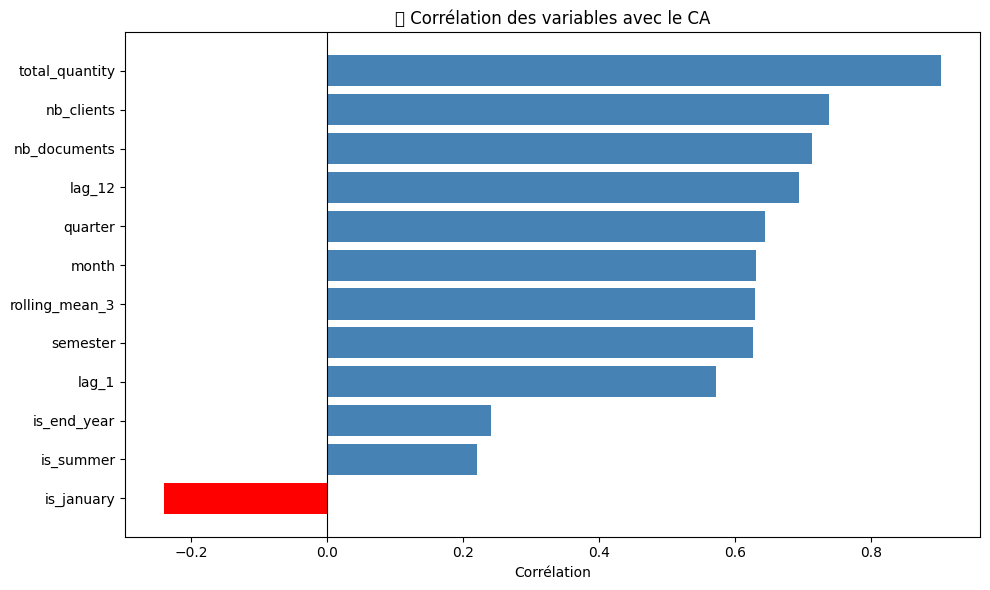


Corrélations :
is_january       -0.24
is_summer         0.22
is_end_year       0.24
lag_1             0.57
semester          0.63
rolling_mean_3    0.63
month             0.63
quarter           0.64
lag_12            0.69
nb_documents      0.71
nb_clients        0.74
total_quantity    0.90


In [6]:
FEATURES = [
    'month', 'quarter', 'semester',
    'total_quantity', 'nb_documents', 'nb_clients',
    'is_summer', 'is_end_year', 'is_january',
    'lag_1', 'lag_12', 'rolling_mean_3'
]
TARGET = 'total_sales'

corr = df_ml[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('📊 Corrélation des variables avec le CA')
ax.set_xlabel('Corrélation')
plt.tight_layout()
plt.show()

print("\nCorrélations :")
print(corr.to_string())

## 4. Sélection finale basée sur la corrélation

In [7]:
# Garder uniquement les variables avec |corrélation| > 0.1
threshold = 0.1
selected = corr[abs(corr) > threshold].index.tolist()

print(f"Variables sélectionnées ({len(selected)}) :")
for f in selected:
    print(f"  • {f:<20} corr = {corr[f]:.3f}")

FEATURES_FINAL = selected
X = df_ml[FEATURES_FINAL]
y = df_ml[TARGET]

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")

Variables sélectionnées (12) :
  • is_january           corr = -0.240
  • is_summer            corr = 0.220
  • is_end_year          corr = 0.241
  • lag_1                corr = 0.572
  • semester             corr = 0.627
  • rolling_mean_3       corr = 0.629
  • month                corr = 0.630
  • quarter              corr = 0.644
  • lag_12               corr = 0.695
  • nb_documents         corr = 0.713
  • nb_clients           corr = 0.739
  • total_quantity       corr = 0.903

X shape : (37, 12)
y shape : (37,)


In [8]:
df_ml.to_csv('/app/notebooks/ml_dataset.csv', index=False)

# Sauvegarder aussi la liste des features sélectionnées
import json
with open('/app/notebooks/selected_features.json', 'w') as f:
    json.dump(FEATURES_FINAL, f)

print(f"✅ Dataset sauvegardé → {df_ml.shape}")
print(f"✅ Features sauvegardées → {FEATURES_FINAL}")

✅ Dataset sauvegardé → (37, 15)
✅ Features sauvegardées → ['is_january', 'is_summer', 'is_end_year', 'lag_1', 'semester', 'rolling_mean_3', 'month', 'quarter', 'lag_12', 'nb_documents', 'nb_clients', 'total_quantity']
